# 02 — DEM Vertical Compression

This notebook loads the gravity-settled particle packing created in Notebook 01.

The model then:

- adds a movable top wall;
- applies vertical effective stress in stages;
- records top-wall displacement;
- calculates vertical strain;
- calculates vertical stress;
- monitors kinetic energy and particle contacts;
- saves the compressed packing for the shear test.

The compression is applied using a simple stress-control servo.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.collections import PatchCollection, LineCollection
from matplotlib.patches import Circle
from scipy.spatial import cKDTree

np.set_printoptions(precision=6, suppress=True)

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_directory = current_directory.parent
else:
    project_directory = current_directory

results_directory = project_directory / "results"
figure_directory = results_directory / "figures"
csv_directory = results_directory / "csv"
restart_directory = results_directory / "restart"

for folder in [
    results_directory,
    figure_directory,
    csv_directory,
    restart_directory,
]:
    folder.mkdir(parents=True, exist_ok=True)

restart_file_path = (
    restart_directory / "settled_particle_packing.npz"
)

print("Project directory:", project_directory)
print("Restart file:", restart_file_path)
print("Restart file exists:", restart_file_path.exists())

Project directory: C:\Users\duaas\dike_fem_dem_project
Restart file: C:\Users\duaas\dike_fem_dem_project\results\restart\settled_particle_packing.npz
Restart file exists: True


In [2]:
# ============================================================
# LOAD THE GRAVITY-SETTLED PACKING
# ============================================================

if not restart_file_path.exists():
    raise FileNotFoundError(
        "The settled packing file was not found. "
        "Run the final saving cell in Notebook 01 first."
    )

restart_data = np.load(
    restart_file_path,
    allow_pickle=True,
)

# Particle state from Notebook 01
positions = restart_data["positions"].copy()
initial_settled_positions = positions.copy()

radii = restart_data["radii"].copy()
masses = restart_data["masses"].copy()

moments_of_inertia = (
    restart_data["moments_of_inertia"].copy()
)

number_of_particles = len(radii)

# Geometry
box_width = float(
    restart_data["box_width"]
)

box_height = float(
    restart_data["box_height"]
)

# Material and dimensional properties
particle_density = float(
    restart_data["particle_density"]
)

particle_thickness = float(
    restart_data["particle_thickness"]
)

# Friction values are retained from Notebook 01.
particle_friction = float(
    restart_data["particle_friction"]
)

wall_friction = float(
    restart_data["wall_friction"]
)

# ============================================================
# CONTACT PARAMETERS USED FOR COMPRESSION
# ============================================================
#
# Notebook 01 used softer contacts to generate the gravity
# packing efficiently. Higher stiffness is introduced here
# because the specimen will be compressed to approximately
# 40 kPa.
#
# These remain numerical demonstration parameters and are not
# calibrated properties of the actual dike sand.
# ============================================================

normal_stiffness = 2.0e5       # N/m
tangential_stiffness = 8.0e4   # N/m

normal_damping = 12.0          # N s/m
tangential_damping = 3.0       # N s/m

# Start compression from a stationary state.
velocities = np.zeros_like(
    positions
)

angular_velocities = np.zeros(
    number_of_particles
)

angles = np.zeros(
    number_of_particles
)

gravity = 9.81

print("Settled packing loaded successfully.")
print("=" * 55)
print("Number of particles:", number_of_particles)
print("Box width:", box_width, "m")
print(
    "Notebook 01 coordination number:",
    float(
        restart_data[
            "final_coordination_number"
        ]
    ),
)
print()
print("Compression contact parameters")
print("-" * 55)
print(
    "Normal stiffness:",
    normal_stiffness,
    "N/m",
)
print(
    "Tangential stiffness:",
    tangential_stiffness,
    "N/m",
)
print(
    "Normal damping:",
    normal_damping,
    "N s/m",
)
print(
    "Tangential damping:",
    tangential_damping,
    "N s/m",
)
print(
    "Particle friction:",
    particle_friction,
)
print(
    "Wall friction:",
    wall_friction,
)

Settled packing loaded successfully.
Number of particles: 120
Box width: 0.12 m
Notebook 01 coordination number: 3.05

Compression contact parameters
-------------------------------------------------------
Normal stiffness: 200000.0 N/m
Tangential stiffness: 80000.0 N/m
Normal damping: 12.0 N s/m
Tangential damping: 3.0 N s/m
Particle friction: 0.5
Wall friction: 0.4


In [3]:
# ============================================================
# NUMERICAL SETTINGS
# ============================================================

# Reduced relative to the original soft-contact simulation,
# but larger than 5e-6 s to keep the runtime manageable.
time_step = 1.0e-5

# Maximum number of steps available for each stress stage.
# The simulation may stop earlier when equilibrium is reached.
maximum_steps_per_stage = 180000

output_interval = 200

equilibrium_check_interval = 500

required_equilibrium_checks = 5

global_velocity_damping = 0.9985

# ============================================================
# TARGET EFFECTIVE VERTICAL STRESSES
# ============================================================

target_vertical_stresses_kPa = [
    5.0,
    10.0,
    20.0,
    40.0,
]

target_vertical_stresses = (
    1000.0
    * np.array(
        target_vertical_stresses_kPa
    )
)

# ============================================================
# TOP-WALL SERVO PARAMETERS
# ============================================================

maximum_top_wall_speed = 0.02    # m/s

minimum_servo_speed = 1.0e-6     # m/s

servo_gain = 0.50

# Each loading stage is accepted when its stress is within
# 3% of the target and the motion criteria are satisfied.
stress_tolerance_fraction = 0.03

kinetic_energy_tolerance = 5.0e-7

maximum_velocity_tolerance = 3.0e-3

# ============================================================
# TOP-WALL INITIAL POSITION
# ============================================================

top_wall_clearance = 2.0e-4

initial_top_wall_y = (
    np.max(
        positions[:, 1] + radii
    )
    + top_wall_clearance
)

top_wall_y = initial_top_wall_y

initial_specimen_height = (
    initial_top_wall_y
)

# Effective wall area for the 2D model, including the assumed
# out-of-plane thickness.
top_wall_area = (
    box_width
    * particle_thickness
)

print("Compression parameters defined.")
print("=" * 55)
print(
    "Initial top-wall position:",
    top_wall_y,
    "m",
)
print(
    "Initial specimen height:",
    initial_specimen_height,
    "m",
)
print(
    "Top-wall area:",
    top_wall_area,
    "m2",
)
print(
    "Target stresses:",
    target_vertical_stresses_kPa,
    "kPa",
)
print(
    "Time step:",
    time_step,
    "s",
)
print(
    "Maximum steps per stage:",
    maximum_steps_per_stage,
)
print(
    "Maximum simulated time per stage:",
    maximum_steps_per_stage
    * time_step,
    "s",
)
print(
    "Maximum top-wall speed:",
    maximum_top_wall_speed,
    "m/s",
)
print(
    "Stress tolerance:",
    100.0
    * stress_tolerance_fraction,
    "%",
)

Compression parameters defined.
Initial top-wall position: 0.0882721033483608 m
Initial specimen height: 0.0882721033483608 m
Top-wall area: 0.0012 m2
Target stresses: [5.0, 10.0, 20.0, 40.0] kPa
Time step: 1e-05 s
Maximum steps per stage: 180000
Maximum simulated time per stage: 1.8 s
Maximum top-wall speed: 0.02 m/s
Stress tolerance: 3.0 %


In [4]:
def calculate_particle_contacts(
    positions,
    velocities,
    angular_velocities,
    radii,
    normal_stiffness,
    tangential_stiffness,
    normal_damping,
    tangential_damping,
    particle_friction,
    time_step,
    tangential_history,
):
    number_of_particles = len(radii)

    forces = np.zeros((number_of_particles, 2))
    torques = np.zeros(number_of_particles)

    active_contacts = set()
    contact_information = []

    search_radius = 2.05 * radii.max()

    tree = cKDTree(positions)

    candidate_pairs = tree.query_pairs(
        r=search_radius
    )

    for i, j in candidate_pairs:

        relative_position = (
            positions[j] - positions[i]
        )

        distance = np.linalg.norm(
            relative_position
        )

        combined_radius = (
            radii[i] + radii[j]
        )

        overlap = (
            combined_radius - distance
        )

        if overlap <= 0.0 or distance <= 1.0e-12:
            continue

        contact_key = (
            min(i, j),
            max(i, j),
        )

        active_contacts.add(contact_key)

        normal_vector = (
            relative_position / distance
        )

        tangential_vector = np.array(
            [
                -normal_vector[1],
                normal_vector[0],
            ]
        )

        relative_velocity = (
            velocities[j] - velocities[i]
        )

        normal_relative_velocity = np.dot(
            relative_velocity,
            normal_vector,
        )

        tangential_relative_velocity = (
            np.dot(
                relative_velocity,
                tangential_vector,
            )
            - angular_velocities[i] * radii[i]
            - angular_velocities[j] * radii[j]
        )

        elastic_normal_force = (
            normal_stiffness * overlap
        )

        damping_normal_force = (
            -normal_damping
            * normal_relative_velocity
        )

        normal_force_magnitude = max(
            0.0,
            elastic_normal_force
            + damping_normal_force,
        )

        previous_tangential_displacement = (
            tangential_history.get(
                contact_key,
                0.0,
            )
        )

        updated_tangential_displacement = (
            previous_tangential_displacement
            + tangential_relative_velocity
            * time_step
        )

        trial_tangential_force = (
            -tangential_stiffness
            * updated_tangential_displacement
            - tangential_damping
            * tangential_relative_velocity
        )

        maximum_tangential_force = (
            particle_friction
            * normal_force_magnitude
        )

        tangential_force_scalar = np.clip(
            trial_tangential_force,
            -maximum_tangential_force,
            maximum_tangential_force,
        )

        if tangential_stiffness > 0.0:
            corrected_tangential_displacement = -(
                tangential_force_scalar
                + tangential_damping
                * tangential_relative_velocity
            ) / tangential_stiffness
        else:
            corrected_tangential_displacement = 0.0

        tangential_history[contact_key] = (
            corrected_tangential_displacement
        )

        normal_force = (
            normal_force_magnitude
            * normal_vector
        )

        tangential_force = (
            tangential_force_scalar
            * tangential_vector
        )

        total_force = (
            normal_force
            + tangential_force
        )

        forces[i] -= total_force
        forces[j] += total_force

        torques[i] += (
            -radii[i]
            * tangential_force_scalar
        )

        torques[j] += (
            -radii[j]
            * tangential_force_scalar
        )

        friction_mobilisation = 0.0

        if (
            maximum_tangential_force
            > 1.0e-12
        ):
            friction_mobilisation = (
                abs(tangential_force_scalar)
                / maximum_tangential_force
            )

        contact_information.append(
            {
                "particle_i": i,
                "particle_j": j,
                "normal_force": normal_force_magnitude,
                "tangential_force": abs(
                    tangential_force_scalar
                ),
                "overlap": overlap,
                "friction_mobilisation":
                    friction_mobilisation,
            }
        )

    inactive_contacts = (
        set(tangential_history.keys())
        - active_contacts
    )

    for contact_key in inactive_contacts:
        tangential_history.pop(
            contact_key,
            None,
        )

    return (
        forces,
        torques,
        contact_information,
        tangential_history,
    )

In [5]:
def calculate_boundary_contacts(
    positions,
    velocities,
    angular_velocities,
    radii,
    box_width,
    top_wall_y,
    top_wall_velocity,
    normal_stiffness,
    tangential_damping,
    normal_damping,
    wall_friction,
):
    number_of_particles = len(radii)

    forces = np.zeros(
        (number_of_particles, 2)
    )

    torques = np.zeros(
        number_of_particles
    )

    top_wall_reaction_force = 0.0

    wall_contact_count = 0

    maximum_wall_overlap = 0.0

    for i in range(number_of_particles):

        x, y = positions[i]

        radius = radii[i]

        wall_contacts = []

        # Left wall
        left_overlap = radius - x

        if left_overlap > 0.0:
            wall_contacts.append(
                {
                    "overlap": left_overlap,
                    "normal": np.array(
                        [1.0, 0.0]
                    ),
                    "tangent": np.array(
                        [0.0, 1.0]
                    ),
                    "wall_velocity":
                        np.array([0.0, 0.0]),
                    "wall_name": "left",
                }
            )

        # Right wall
        right_overlap = (
            x + radius - box_width
        )

        if right_overlap > 0.0:
            wall_contacts.append(
                {
                    "overlap": right_overlap,
                    "normal": np.array(
                        [-1.0, 0.0]
                    ),
                    "tangent": np.array(
                        [0.0, 1.0]
                    ),
                    "wall_velocity":
                        np.array([0.0, 0.0]),
                    "wall_name": "right",
                }
            )

        # Bottom wall
        bottom_overlap = radius - y

        if bottom_overlap > 0.0:
            wall_contacts.append(
                {
                    "overlap": bottom_overlap,
                    "normal": np.array(
                        [0.0, 1.0]
                    ),
                    "tangent": np.array(
                        [1.0, 0.0]
                    ),
                    "wall_velocity":
                        np.array([0.0, 0.0]),
                    "wall_name": "bottom",
                }
            )

        # Top wall
        top_overlap = (
            y + radius - top_wall_y
        )

        if top_overlap > 0.0:
            wall_contacts.append(
                {
                    "overlap": top_overlap,
                    "normal": np.array(
                        [0.0, -1.0]
                    ),
                    "tangent": np.array(
                        [1.0, 0.0]
                    ),
                    "wall_velocity":
                        np.array(
                            [0.0, top_wall_velocity]
                        ),
                    "wall_name": "top",
                }
            )

        for wall_contact in wall_contacts:

            overlap = (
                wall_contact["overlap"]
            )

            normal_vector = (
                wall_contact["normal"]
            )

            tangential_vector = (
                wall_contact["tangent"]
            )

            wall_velocity_vector = (
                wall_contact["wall_velocity"]
            )

            wall_name = (
                wall_contact["wall_name"]
            )

            wall_contact_count += 1

            maximum_wall_overlap = max(
                maximum_wall_overlap,
                overlap,
            )

            relative_velocity = (
                velocities[i]
                - wall_velocity_vector
            )

            normal_relative_velocity = np.dot(
                relative_velocity,
                normal_vector,
            )

            tangential_relative_velocity = (
                np.dot(
                    relative_velocity,
                    tangential_vector,
                )
                - angular_velocities[i]
                * radius
            )

            normal_force_magnitude = max(
                0.0,
                normal_stiffness * overlap
                - normal_damping
                * normal_relative_velocity,
            )

            tangential_force_scalar = (
                -tangential_damping
                * tangential_relative_velocity
            )

            maximum_tangential_force = (
                wall_friction
                * normal_force_magnitude
            )

            tangential_force_scalar = np.clip(
                tangential_force_scalar,
                -maximum_tangential_force,
                maximum_tangential_force,
            )

            normal_force = (
                normal_force_magnitude
                * normal_vector
            )

            tangential_force = (
                tangential_force_scalar
                * tangential_vector
            )

            forces[i] += (
                normal_force
                + tangential_force
            )

            torques[i] += (
                -radius
                * tangential_force_scalar
            )

            if wall_name == "top":
                top_wall_reaction_force += (
                    normal_force_magnitude
                )

    return (
        forces,
        torques,
        top_wall_reaction_force,
        wall_contact_count,
        maximum_wall_overlap,
    )

In [6]:
tangential_history = {}

compression_records = []

stage_summary_records = []

global_step = 0

last_contact_information = []

print("Starting staged vertical compression...")
print()

for stage_index, target_stress in enumerate(
    target_vertical_stresses
):

    target_stress_kPa = (
        target_stress / 1000.0
    )

    print(
        f"Stage {stage_index + 1}: "
        f"target stress = "
        f"{target_stress_kPa:.1f} kPa"
    )

    consecutive_equilibrium_checks = 0

    stage_equilibrium_reached = False

    for stage_step in range(
        maximum_steps_per_stage
    ):

        global_step += 1

        particle_forces = np.zeros_like(
            positions
        )

        particle_torques = np.zeros(
            number_of_particles
        )

        # Gravity remains active during compression.
        particle_forces[:, 1] -= (
            masses * gravity
        )

        # ----------------------------------------------------
        # PARTICLE-PARTICLE CONTACTS
        # ----------------------------------------------------

        (
            contact_forces,
            contact_torques,
            contact_information,
            tangential_history,
        ) = calculate_particle_contacts(
            positions=positions,
            velocities=velocities,
            angular_velocities=
                angular_velocities,
            radii=radii,
            normal_stiffness=
                normal_stiffness,
            tangential_stiffness=
                tangential_stiffness,
            normal_damping=
                normal_damping,
            tangential_damping=
                tangential_damping,
            particle_friction=
                particle_friction,
            time_step=time_step,
            tangential_history=
                tangential_history,
        )

        # ----------------------------------------------------
        # FIRST WALL-FORCE CALCULATION
        #
        # The present wall force is calculated using a
        # temporarily stationary top wall. This stress is used
        # by the servo controller.
        # ----------------------------------------------------

        (
            wall_forces,
            wall_torques,
            top_wall_force,
            wall_contact_count,
            maximum_wall_overlap,
        ) = calculate_boundary_contacts(
            positions=positions,
            velocities=velocities,
            angular_velocities=
                angular_velocities,
            radii=radii,
            box_width=box_width,
            top_wall_y=top_wall_y,
            top_wall_velocity=0.0,
            normal_stiffness=
                normal_stiffness,
            tangential_damping=
                tangential_damping,
            normal_damping=
                normal_damping,
            wall_friction=
                wall_friction,
        )

        current_vertical_stress = (
            top_wall_force
            / top_wall_area
        )

        stress_error = (
            target_stress
            - current_vertical_stress
        )

        normalised_stress_error = (
            stress_error
            / max(target_stress, 1.0)
        )

        # ----------------------------------------------------
        # STRESS-CONTROL SERVO
        #
        # Positive stress error means that the current stress
        # is below the target. The top wall must therefore move
        # downward, which corresponds to a negative velocity.
        # ----------------------------------------------------

        top_wall_velocity = np.clip(
            -servo_gain
            * normalised_stress_error
            * maximum_top_wall_speed,
            -maximum_top_wall_speed,
            maximum_top_wall_speed,
        )

        # Near the target, use only a very small correction
        # velocity to prevent large oscillations.
        if (
            abs(normalised_stress_error)
            < stress_tolerance_fraction
        ):

            top_wall_velocity = (
                -np.sign(
                    normalised_stress_error
                )
                * minimum_servo_speed
            )

            # Stop the wall when the stress error is within
            # 0.5% of the target.
            if (
                abs(normalised_stress_error)
                < 0.005
            ):
                top_wall_velocity = 0.0

        elif (
            abs(top_wall_velocity)
            < minimum_servo_speed
        ):

            top_wall_velocity = (
                -np.sign(
                    normalised_stress_error
                )
                * minimum_servo_speed
            )

        # ----------------------------------------------------
        # SECOND WALL-FORCE CALCULATION
        #
        # Boundary forces are recalculated using the actual
        # servo-controlled top-wall velocity.
        # ----------------------------------------------------

        (
            wall_forces,
            wall_torques,
            top_wall_force,
            wall_contact_count,
            maximum_wall_overlap,
        ) = calculate_boundary_contacts(
            positions=positions,
            velocities=velocities,
            angular_velocities=
                angular_velocities,
            radii=radii,
            box_width=box_width,
            top_wall_y=top_wall_y,
            top_wall_velocity=
                top_wall_velocity,
            normal_stiffness=
                normal_stiffness,
            tangential_damping=
                tangential_damping,
            normal_damping=
                normal_damping,
            wall_friction=
                wall_friction,
        )

        current_vertical_stress = (
            top_wall_force
            / top_wall_area
        )

        # ----------------------------------------------------
        # TOTAL FORCES AND MOTION INTEGRATION
        # ----------------------------------------------------

        particle_forces += contact_forces
        particle_forces += wall_forces

        particle_torques += contact_torques
        particle_torques += wall_torques

        accelerations = (
            particle_forces
            / masses[:, np.newaxis]
        )

        angular_accelerations = (
            particle_torques
            / moments_of_inertia
        )

        velocities += (
            accelerations * time_step
        )

        angular_velocities += (
            angular_accelerations
            * time_step
        )

        velocities *= (
            global_velocity_damping
        )

        angular_velocities *= (
            global_velocity_damping
        )

        positions += (
            velocities * time_step
        )

        angles += (
            angular_velocities
            * time_step
        )

        top_wall_y += (
            top_wall_velocity
            * time_step
        )

        # Prevent the top wall from crossing the bottom wall.
        if top_wall_y <= 0.0:
            raise RuntimeError(
                "The top wall crossed the bottom boundary. "
                "Reduce the wall speed or inspect the servo."
            )

        # ----------------------------------------------------
        # RESPONSE QUANTITIES
        # ----------------------------------------------------

        current_height = top_wall_y

        vertical_strain = (
            initial_specimen_height
            - current_height
        ) / initial_specimen_height

        translational_kinetic_energy = (
            0.5
            * np.sum(
                masses[:, np.newaxis]
                * velocities**2
            )
        )

        rotational_kinetic_energy = (
            0.5
            * np.sum(
                moments_of_inertia
                * angular_velocities**2
            )
        )

        total_kinetic_energy = (
            translational_kinetic_energy
            + rotational_kinetic_energy
        )

        maximum_velocity = np.max(
            np.linalg.norm(
                velocities,
                axis=1,
            )
        )

        number_of_contacts = len(
            contact_information
        )

        coordination_number = (
            2.0
            * number_of_contacts
            / number_of_particles
        )

        if contact_information:

            maximum_particle_overlap = max(
                contact["overlap"]
                for contact
                in contact_information
            )

            mean_friction_mobilisation = (
                np.mean(
                    [
                        contact[
                            "friction_mobilisation"
                        ]
                        for contact
                        in contact_information
                    ]
                )
            )

            sliding_contact_count = sum(
                contact[
                    "friction_mobilisation"
                ] >= 0.99
                for contact
                in contact_information
            )

        else:

            maximum_particle_overlap = 0.0

            mean_friction_mobilisation = 0.0

            sliding_contact_count = 0

        maximum_overlap = max(
            maximum_particle_overlap,
            maximum_wall_overlap,
        )

        stress_error_fraction = (
            abs(
                current_vertical_stress
                - target_stress
            )
            / target_stress
        )

        # ----------------------------------------------------
        # SAVE HISTORY
        # ----------------------------------------------------

        if global_step % output_interval == 0:

            compression_records.append(
                {
                    "global_step":
                        global_step,
                    "stage":
                        stage_index + 1,
                    "target_stress_kPa":
                        target_stress_kPa,
                    "time_s":
                        global_step
                        * time_step,
                    "top_wall_y_m":
                        top_wall_y,
                    "top_wall_velocity_m_per_s":
                        top_wall_velocity,
                    "vertical_stress_kPa":
                        current_vertical_stress
                        / 1000.0,
                    "vertical_strain":
                        vertical_strain,
                    "stress_error_fraction":
                        stress_error_fraction,
                    "kinetic_energy_J":
                        total_kinetic_energy,
                    "maximum_velocity_m_per_s":
                        maximum_velocity,
                    "coordination_number":
                        coordination_number,
                    "particle_contacts":
                        number_of_contacts,
                    "sliding_contacts":
                        sliding_contact_count,
                    "mean_friction_mobilisation":
                        mean_friction_mobilisation,
                    "maximum_overlap_m":
                        maximum_overlap,
                }
            )

        # ----------------------------------------------------
        # EQUILIBRIUM CHECK
        # ----------------------------------------------------

        if (
            stage_step
            % equilibrium_check_interval
            == 0
            and stage_step > 1000
        ):

            equilibrium_condition = (
                stress_error_fraction
                < stress_tolerance_fraction
                and total_kinetic_energy
                < kinetic_energy_tolerance
                and maximum_velocity
                < maximum_velocity_tolerance
            )

            if equilibrium_condition:

                consecutive_equilibrium_checks += 1

            else:

                consecutive_equilibrium_checks = 0

            if (
                consecutive_equilibrium_checks
                >= required_equilibrium_checks
            ):

                stage_equilibrium_reached = True

                print(
                    f"  Equilibrium reached at "
                    f"{current_vertical_stress / 1000.0:.3f} kPa"
                )

                break

        # ----------------------------------------------------
        # PROGRESS PRINTING
        # ----------------------------------------------------

        if stage_step % 10000 == 0:

            print(
                f"  Step {stage_step:6d} | "
                f"stress = "
                f"{current_vertical_stress / 1000.0:7.3f} kPa | "
                f"strain = "
                f"{vertical_strain:8.5f} | "
                f"KE = "
                f"{total_kinetic_energy:.3e} J | "
                f"error = "
                f"{100.0 * stress_error_fraction:6.2f}%"
            )

        last_contact_information = (
            contact_information
        )

    # --------------------------------------------------------
    # STAGE SUMMARY
    # --------------------------------------------------------

    stage_summary_records.append(
        {
            "stage":
                stage_index + 1,
            "target_stress_kPa":
                target_stress_kPa,
            "achieved_stress_kPa":
                current_vertical_stress
                / 1000.0,
            "stress_error_percent":
                100.0
                * stress_error_fraction,
            "vertical_strain":
                vertical_strain,
            "top_wall_y_m":
                top_wall_y,
            "kinetic_energy_J":
                total_kinetic_energy,
            "maximum_velocity_m_per_s":
                maximum_velocity,
            "coordination_number":
                coordination_number,
            "particle_contacts":
                number_of_contacts,
            "sliding_contacts":
                sliding_contact_count,
            "maximum_overlap_m":
                maximum_overlap,
            "equilibrium_reached":
                stage_equilibrium_reached,
        }
    )

    print(
        f"  Stage complete: "
        f"stress = "
        f"{current_vertical_stress / 1000.0:.3f} kPa, "
        f"error = "
        f"{100.0 * stress_error_fraction:.2f}%, "
        f"strain = "
        f"{vertical_strain:.5f}, "
        f"Z = "
        f"{coordination_number:.3f}, "
        f"equilibrium = "
        f"{stage_equilibrium_reached}"
    )

    print()

    last_contact_information = (
        contact_information
    )

print("All compression stages completed.")

Starting staged vertical compression...

Stage 1: target stress = 5.0 kPa
  Step      0 | stress =   0.000 kPa | strain =  0.00000 | KE = 8.978e-07 J | error = 100.00%
  Step  10000 | stress =   0.730 kPa | strain =  0.01046 | KE = 2.906e-06 J | error =  85.41%
  Step  20000 | stress =   1.266 kPa | strain =  0.01907 | KE = 5.351e-06 J | error =  74.68%
  Step  30000 | stress =   4.744 kPa | strain =  0.02361 | KE = 2.609e-07 J | error =   5.12%
  Step  40000 | stress =   4.086 kPa | strain =  0.02533 | KE = 1.504e-06 J | error =  18.29%
  Equilibrium reached at 4.863 kPa
  Stage complete: stress = 4.863 kPa, error = 2.74%, strain = 0.02621, Z = 2.967, equilibrium = True

Stage 2: target stress = 10.0 kPa
  Step      0 | stress =   5.223 kPa | strain =  0.02621 | KE = 8.103e-10 J | error =  47.77%
  Equilibrium reached at 9.706 kPa
  Stage complete: stress = 9.706 kPa, error = 2.94%, strain = 0.02734, Z = 2.983, equilibrium = True

Stage 3: target stress = 20.0 kPa
  Step      0 | stre

In [7]:
compression_dataframe = pd.DataFrame(
    compression_records
)

stage_summary_dataframe = pd.DataFrame(
    stage_summary_records
)

stage_summary_dataframe

,stage,target_stress_kPa,achieved_stress_kPa,stress_error_percent,vertical_strain,top_wall_y_m,kinetic_energy_J,maximum_velocity_m_per_s,coordination_number,particle_contacts,sliding_contacts,maximum_overlap_m,equilibrium_reached
0,1,5.0,4.863092,2.738158,0.026207,0.085959,3.201030e-14,0.000001,2.966667,178,11,0.000012,True
1,2,10.0,9.705532,2.944685,0.027341,0.085859,3.549500e-14,0.000001,2.983333,179,12,0.000020,True
2,3,20.0,19.409143,2.954283,0.029431,0.085674,1.426083e-09,0.000945,3.000000,180,13,0.000033,True
3,4,40.0,38.800417,2.998958,0.032783,0.085378,1.736765e-12,0.000008,3.083333,185,17,0.000060,True


In [8]:
final_vertical_stress = (
    current_vertical_stress
)

final_vertical_strain = (
    vertical_strain
)

final_coordination_number = (
    coordination_number
)

final_kinetic_energy = (
    total_kinetic_energy
)

final_maximum_velocity = (
    maximum_velocity
)

final_maximum_overlap = (
    maximum_overlap
)

relative_maximum_overlap = (
    final_maximum_overlap
    / radii.min()
)

print("FINAL COMPRESSION DIAGNOSTICS")
print("=" * 55)
print(
    f"Final vertical stress     : "
    f"{final_vertical_stress / 1000.0:.4f} kPa"
)
print(
    f"Final vertical strain     : "
    f"{final_vertical_strain:.6f}"
)
print(
    f"Final top-wall position   : "
    f"{top_wall_y:.6f} m"
)
print(
    f"Final coordination number : "
    f"{final_coordination_number:.3f}"
)
print(
    f"Final kinetic energy      : "
    f"{final_kinetic_energy:.4e} J"
)
print(
    f"Maximum velocity          : "
    f"{final_maximum_velocity:.4e} m/s"
)
print(
    f"Maximum overlap           : "
    f"{final_maximum_overlap:.4e} m"
)
print(
    f"Relative maximum overlap  : "
    f"{relative_maximum_overlap:.4%}"
)

FINAL COMPRESSION DIAGNOSTICS
Final vertical stress     : 38.8004 kPa
Final vertical strain     : 0.032783
Final top-wall position   : 0.085378 m
Final coordination number : 3.083
Final kinetic energy      : 1.7368e-12 J
Maximum velocity          : 8.1396e-06 m/s
Maximum overlap           : 5.9574e-05 m
Relative maximum overlap  : 1.6950%


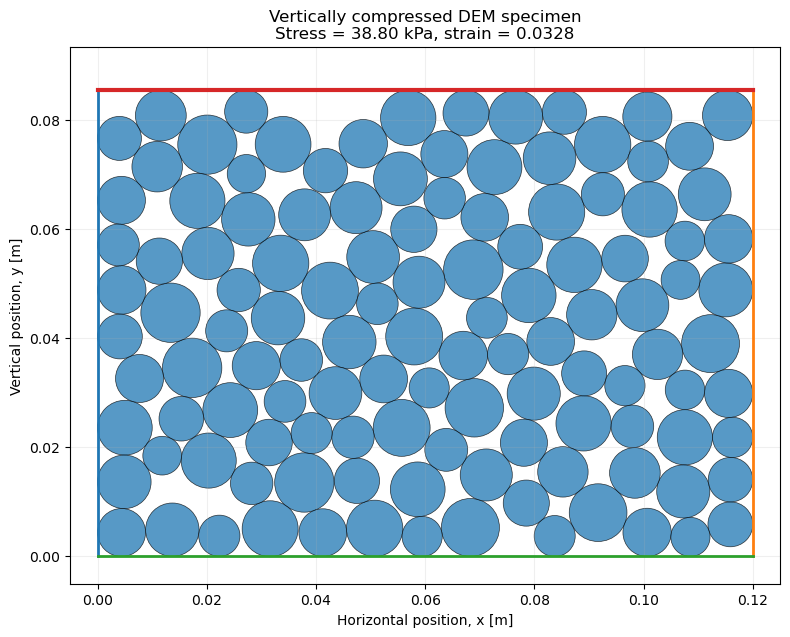

In [9]:
def plot_compressed_specimen(
    positions,
    radii,
    box_width,
    top_wall_y,
    vertical_stress_kPa,
    vertical_strain,
    save_path=None,
):
    fig, ax = plt.subplots(
        figsize=(8, 8)
    )

    circles = [
        Circle(
            (
                positions[i, 0],
                positions[i, 1],
            ),
            radii[i],
        )
        for i in range(len(radii))
    ]

    collection = PatchCollection(
        circles,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.75,
    )

    ax.add_collection(collection)

    ax.plot(
        [0.0, 0.0],
        [0.0, top_wall_y],
        linewidth=2,
    )

    ax.plot(
        [box_width, box_width],
        [0.0, top_wall_y],
        linewidth=2,
    )

    ax.plot(
        [0.0, box_width],
        [0.0, 0.0],
        linewidth=2,
    )

    ax.plot(
        [0.0, box_width],
        [top_wall_y, top_wall_y],
        linewidth=3,
    )

    ax.set_xlim(
        -0.005,
        box_width + 0.005,
    )

    ax.set_ylim(
        -0.005,
        initial_specimen_height + 0.005,
    )

    ax.set_aspect("equal")

    ax.set_xlabel(
        "Horizontal position, x [m]"
    )

    ax.set_ylabel(
        "Vertical position, y [m]"
    )

    ax.set_title(
        "Vertically compressed DEM specimen\n"
        f"Stress = {vertical_stress_kPa:.2f} kPa, "
        f"strain = {vertical_strain:.4f}"
    )

    ax.grid(alpha=0.2)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()


plot_compressed_specimen(
    positions=positions,
    radii=radii,
    box_width=box_width,
    top_wall_y=top_wall_y,
    vertical_stress_kPa=
        final_vertical_stress / 1000.0,
    vertical_strain=
        final_vertical_strain,
    save_path=(
        figure_directory
        / "07_compressed_dem_specimen.png"
    ),
)

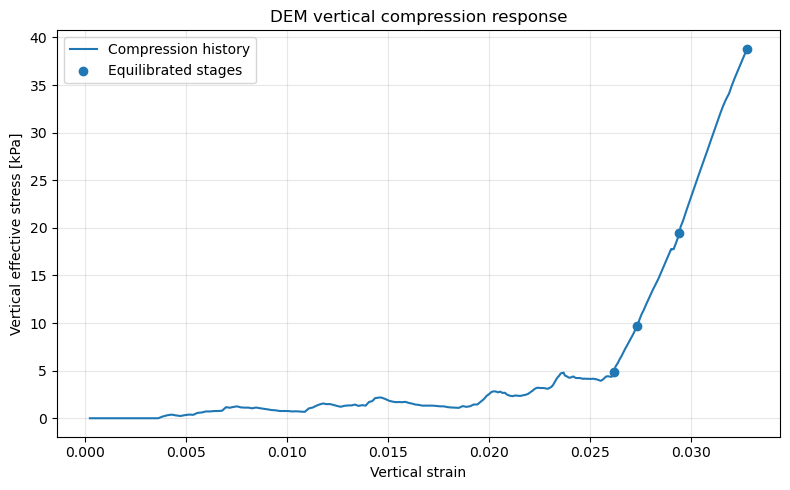

In [10]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    compression_dataframe[
        "vertical_strain"
    ],
    compression_dataframe[
        "vertical_stress_kPa"
    ],
    label="Compression history",
)

# Plot stages that reached equilibrium.
equilibrated_stages = (
    stage_summary_dataframe[
        stage_summary_dataframe[
            "equilibrium_reached"
        ]
    ]
)

if not equilibrated_stages.empty:

    ax.scatter(
        equilibrated_stages[
            "vertical_strain"
        ],
        equilibrated_stages[
            "achieved_stress_kPa"
        ],
        zorder=3,
        label="Equilibrated stages",
    )

# Plot stages that ended without reaching equilibrium.
non_equilibrated_stages = (
    stage_summary_dataframe[
        ~stage_summary_dataframe[
            "equilibrium_reached"
        ]
    ]
)

if not non_equilibrated_stages.empty:

    ax.scatter(
        non_equilibrated_stages[
            "vertical_strain"
        ],
        non_equilibrated_stages[
            "achieved_stress_kPa"
        ],
        marker="x",
        s=80,
        zorder=3,
        label="Non-equilibrated stage ends",
    )

ax.set_xlabel(
    "Vertical strain"
)

ax.set_ylabel(
    "Vertical effective stress [kPa]"
)

ax.set_title(
    "DEM vertical compression response"
)

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()

plt.savefig(
    figure_directory
    / "08_vertical_stress_strain.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

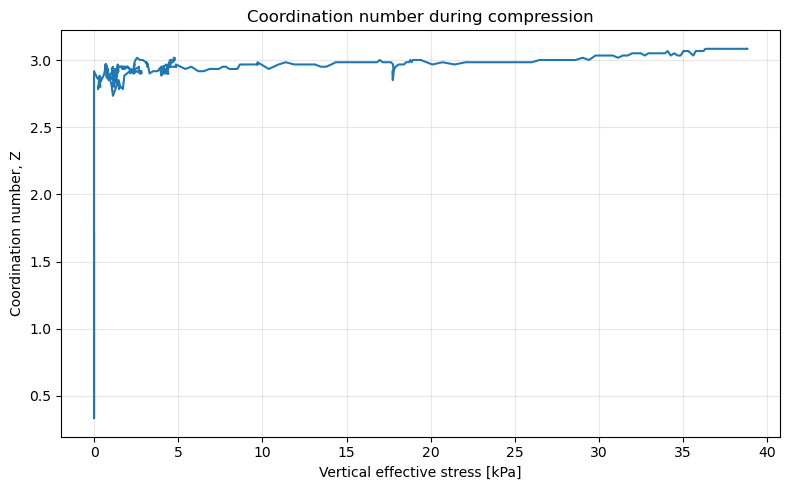

In [11]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    compression_dataframe[
        "vertical_stress_kPa"
    ],
    compression_dataframe[
        "coordination_number"
    ],
)

ax.set_xlabel(
    "Vertical effective stress [kPa]"
)

ax.set_ylabel(
    "Coordination number, Z"
)

ax.set_title(
    "Coordination number during compression"
)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figure_directory
    / "09_coordination_number_compression.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

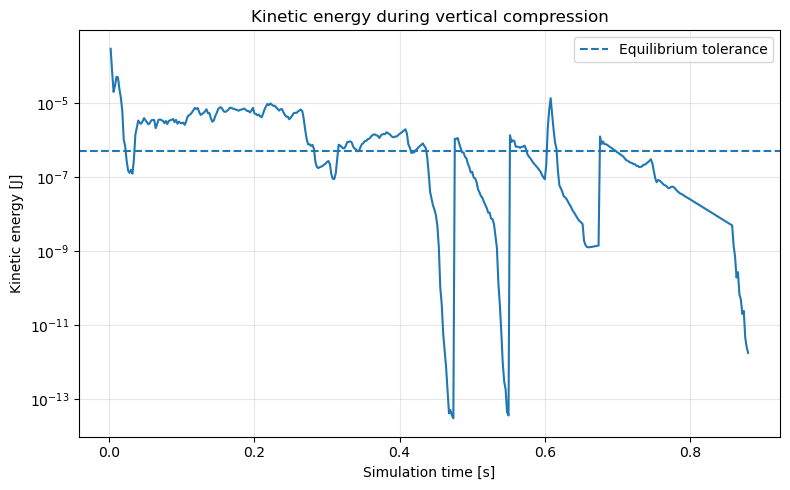

In [12]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.semilogy(
    compression_dataframe[
        "time_s"
    ],
    compression_dataframe[
        "kinetic_energy_J"
    ],
)

ax.axhline(
    kinetic_energy_tolerance,
    linestyle="--",
    label="Equilibrium tolerance",
)

ax.set_xlabel(
    "Simulation time [s]"
)

ax.set_ylabel(
    "Kinetic energy [J]"
)

ax.set_title(
    "Kinetic energy during vertical compression"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    figure_directory
    / "10_compression_kinetic_energy.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [13]:
compressed_particle_dataframe = pd.DataFrame(
    {
        "particle_id":
            np.arange(number_of_particles),
        "x_m":
            positions[:, 0],
        "y_m":
            positions[:, 1],
        "radius_m":
            radii,
        "mass_kg":
            masses,
        "velocity_x_m_per_s":
            velocities[:, 0],
        "velocity_y_m_per_s":
            velocities[:, 1],
        "angle_rad":
            angles,
        "angular_velocity_rad_per_s":
            angular_velocities,
        "compression_displacement_x_m":
            positions[:, 0]
            - initial_settled_positions[:, 0],
        "compression_displacement_y_m":
            positions[:, 1]
            - initial_settled_positions[:, 1],
    }
)

compressed_particle_csv_path = (
    csv_directory
    / "compressed_particle_packing.csv"
)

compression_history_csv_path = (
    csv_directory
    / "vertical_compression_history.csv"
)

stage_summary_csv_path = (
    csv_directory
    / "vertical_compression_stage_summary.csv"
)

compressed_restart_file_path = (
    restart_directory
    / "compressed_particle_packing.npz"
)

compressed_particle_dataframe.to_csv(
    compressed_particle_csv_path,
    index=False,
)

compression_dataframe.to_csv(
    compression_history_csv_path,
    index=False,
)

stage_summary_dataframe.to_csv(
    stage_summary_csv_path,
    index=False,
)

np.savez(
    compressed_restart_file_path,
    positions=positions,
    initial_settled_positions=
        initial_settled_positions,
    velocities=velocities,
    radii=radii,
    masses=masses,
    angles=angles,
    angular_velocities=
        angular_velocities,
    moments_of_inertia=
        moments_of_inertia,
    box_width=box_width,
    top_wall_y=top_wall_y,
    initial_specimen_height=
        initial_specimen_height,
    particle_density=
        particle_density,
    particle_thickness=
        particle_thickness,
    normal_stiffness=
        normal_stiffness,
    tangential_stiffness=
        tangential_stiffness,
    normal_damping=
        normal_damping,
    tangential_damping=
        tangential_damping,
    particle_friction=
        particle_friction,
    wall_friction=
        wall_friction,
    final_vertical_stress=
        final_vertical_stress,
    final_vertical_strain=
        final_vertical_strain,
    final_coordination_number=
        final_coordination_number,
    final_kinetic_energy=
        final_kinetic_energy,
)

print("Compressed packing saved successfully.")
print()
print("Restart file:")
print(compressed_restart_file_path)

Compressed packing saved successfully.

Restart file:
C:\Users\duaas\dike_fem_dem_project\results\restart\compressed_particle_packing.npz
